In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from prophet import Prophet
from sklearn.cluster import KMeans

df = pd.read_csv('../data/turistas.csv')
df.head()

,anio,ciudad,tipo_turismo,visitantes,gasto_promedio
0,2020,Asunción,Cultural,38181,429
1,2020,Asunción,Compras,38670,453
2,2020,Asunción,Receptivo,18104,249
3,2020,Encarnación,Cultural,30230,417
4,2020,Encarnación,Compras,16472,385


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   anio            54 non-null     int64 
 1   ciudad          54 non-null     object
 2   tipo_turismo    54 non-null     object
 3   visitantes      54 non-null     int64 
 4   gasto_promedio  54 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 2.2+ KB
None
              anio    visitantes  gasto_promedio
count    54.000000     54.000000       54.000000
mean   2022.500000  27901.259259      338.277778
std       1.723861   7747.925444       93.419811
min    2020.000000  12025.000000      202.000000
25%    2021.000000  23050.750000      246.000000
50%    2022.500000  30239.500000      338.000000
75%    2024.000000  33436.000000      435.000000
max    2025.000000  38670.000000      482.000000


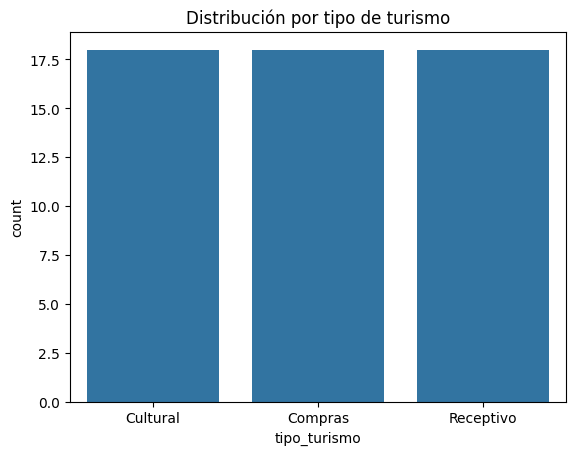

In [2]:
print(df.info())
print(df.describe())

sns.countplot(x='tipo_turismo', data=df)
plt.title('Distribución por tipo de turismo')
plt.show()

In [3]:
m = folium.Map(location=[-25.3, -57.6], zoom_start=6)
for idx, row in df.iterrows():
    folium.Marker(
        location=[-25.3 + idx*0.1, -57.6 + idx*0.1],
        popup=f"{row['ciudad']} - {row['tipo_turismo']} ({row['visitantes']} visitantes)"
    ).add_to(m)
m

10:16:03 - cmdstanpy - INFO - Chain [1] start processing
10:16:03 - cmdstanpy - INFO - Chain [1] done processing
/Users/carlosdomingoalmeidadelgado/miniforge3/lib/python3.12/site-packages/prophet/forecaster.py:1872: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


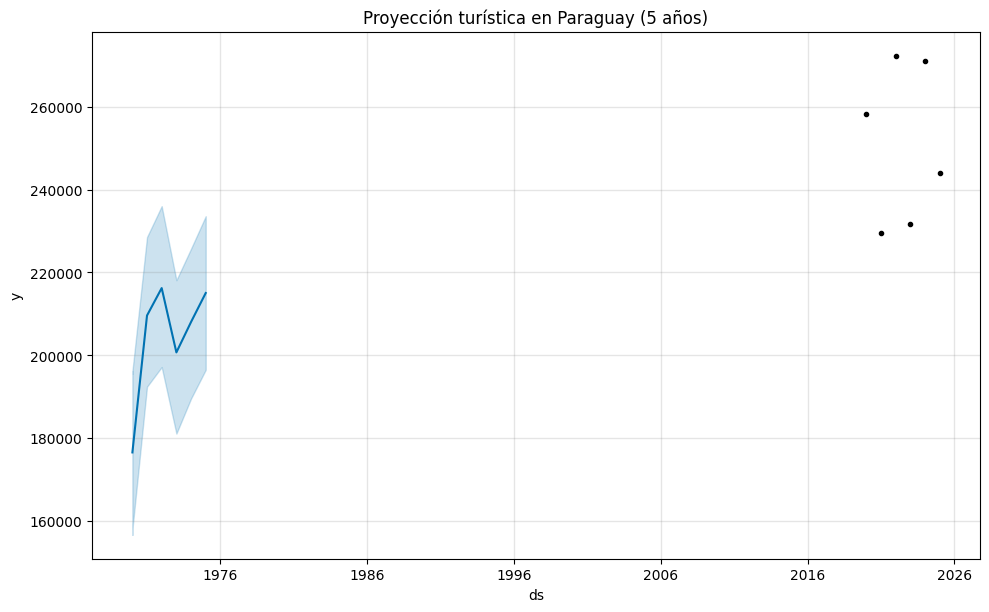

In [5]:
df_agg = df.groupby('anio')['visitantes'].sum().reset_index()
df_agg = df_agg.rename(columns={'anio': 'ds', 'visitantes': 'y'})

model = Prophet()
model.fit(df_agg)

future = model.make_future_dataframe(periods=5, freq='Y')
forecast = model.predict(future)

fig = model.plot(forecast)
plt.title('Proyección turística en Paraguay (5 años)')
plt.show()

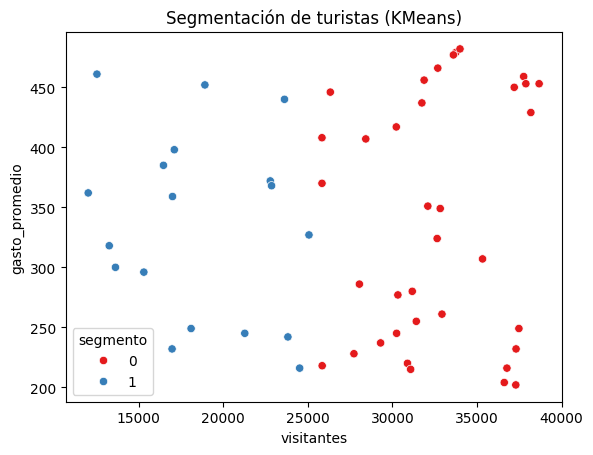

In [6]:
X = df[['visitantes', 'gasto_promedio']]
kmeans = KMeans(n_clusters=2, random_state=42).fit(X)
df['segmento'] = kmeans.labels_

sns.scatterplot(x='visitantes', y='gasto_promedio', hue='segmento', data=df, palette='Set1')
plt.title('Segmentación de turistas (KMeans)')
plt.show()